# Predicción de inasistencia a citas nutricionales

## Proyecto Rubí Ramos

Esta libreta presenta el proceso completo de preparación
de datos, entrenamiento, evaluación y exportación de un
modelo de aprendizaje automático para predecir el riesgo
de inasistencia de un paciente a una cita nutricional.

### Objetivo

Desarrollar un modelo de clasificación que estime si un
paciente asistirá o no a una cita, utilizando:

- Edad y género del paciente.
- Día y hora de la cita.
- Historial de citas completadas.
- Historial de inasistencias.
- Historial de cancelaciones.
- Porcentaje histórico de asistencia.

### Variable objetivo

- `no_show = 0`: el paciente asistió.
- `no_show = 1`: el paciente no asistió.

### Modelos evaluados

1. Regresión logística.
2. Bosque aleatorio.

El anticipo no se utiliza como variable del modelo,
porque la predicción servirá para decidir si debe
solicitarse un anticipo.


## 1. Importación de librerías

Se utilizan:

- `pandas` para procesar los datos.
- `scikit-learn` para entrenar los modelos.
- `matplotlib` para generar gráficas.
- `joblib` para guardar el modelo.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display

from sklearn.ensemble import (
    RandomForestClassifier,
)

from sklearn.linear_model import (
    LogisticRegression,
)

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.model_selection import (
    GroupShuffleSplit,
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
)


RANDOM_STATE = 42

pd.set_option(
    "display.max_columns",
    None,
)

pd.set_option(
    "display.width",
    160,
)

print(
    "Librerías importadas correctamente."
)


Librerías importadas correctamente.


## 2. Localización del dataset

La libreta busca automáticamente el archivo
`dataset_asistencia.csv`.

Puede ejecutarse desde la carpeta `ML` o desde la raíz
del proyecto.


In [2]:
CURRENT_DIR = Path.cwd()

possible_paths = [
    CURRENT_DIR
    / "dataset_asistencia.csv",

    CURRENT_DIR
    / "ML"
    / "dataset_asistencia.csv",
]

DATA_PATH = next(
    (
        path
        for path in possible_paths
        if path.exists()
    ),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró "
        "dataset_asistencia.csv. "
        "Coloca la libreta dentro de ML."
    )

ML_DIR = DATA_PATH.parent

MODEL_PATH = (
    ML_DIR
    / "modelo_inasistencia.joblib"
)

METRICS_PATH = (
    ML_DIR
    / "metricas_modelo.json"
)

IMPORTANCE_PATH = (
    ML_DIR
    / "importancia_variables.csv"
)

PREDICTIONS_PATH = (
    ML_DIR
    / "predicciones_prueba.csv"
)

CONFUSION_MATRIX_PATH = (
    ML_DIR
    / "matriz_confusion.png"
)

print(
    "Dataset encontrado en:",
    DATA_PATH,
)

print(
    "Resultados guardados en:",
    ML_DIR,
)


Dataset encontrado en: C:\Users\rmera\OneDrive\Desktop\proyecto final rubi ramos\RubiRamos\ML\dataset_asistencia.csv
Resultados guardados en: C:\Users\rmera\OneDrive\Desktop\proyecto final rubi ramos\RubiRamos\ML


## 3. Carga del conjunto de datos


In [3]:
df = pd.read_csv(
    DATA_PATH
)

print(
    f"Cantidad de registros: "
    f"{df.shape[0]}"
)

print(
    f"Cantidad de columnas: "
    f"{df.shape[1]}"
)

display(
    df.head()
)


Cantidad de registros: 1232
Cantidad de columnas: 16


,appointment_id,patient_id,appointment_date,age,gender_female,deposit_paid,deposit_amount,day_of_week,appointment_hour,is_saturday,previous_completed,previous_no_show,previous_cancelled,previous_appointments,previous_attendance_rate,attended
0,77,17,2025-01-02,25,0,1,100.0,4,8,0,0,0,0,0,0.0,1
1,78,18,2025-01-02,32,1,1,100.0,4,9,0,0,0,0,0,0.0,1
2,79,19,2025-01-02,39,0,1,100.0,4,10,0,0,0,0,0,0.0,1
3,80,20,2025-01-02,46,1,1,100.0,4,11,0,0,0,0,0,0.0,1
4,81,21,2025-01-02,53,0,1,100.0,4,12,0,0,0,0,0,0.0,1


## 4. Exploración inicial

Se revisan las columnas disponibles, los tipos de datos
y la cantidad de valores faltantes.


In [4]:
print(
    "Columnas disponibles:"
)

for column in df.columns:
    print(
        f"- {column}"
    )

print(
    "\nTipos de datos:"
)

display(
    df.dtypes.to_frame(
        "tipo"
    )
)

print(
    "\nValores faltantes:"
)

missing_values = (
    df.isna()
    .sum()
    .sort_values(
        ascending=False
    )
    .to_frame(
        "valores_faltantes"
    )
)

display(
    missing_values
)


Columnas disponibles:
- appointment_id
- patient_id
- appointment_date
- age
- gender_female
- deposit_paid
- deposit_amount
- day_of_week
- appointment_hour
- is_saturday
- previous_completed
- previous_no_show
- previous_cancelled
- previous_appointments
- previous_attendance_rate
- attended

Tipos de datos:


,tipo
appointment_id,int64
patient_id,int64
appointment_date,str
age,int64
gender_female,int64
deposit_paid,int64
deposit_amount,float64
day_of_week,int64
appointment_hour,int64
is_saturday,int64



Valores faltantes:


,valores_faltantes
appointment_id,0
patient_id,0
appointment_date,0
age,0
gender_female,0
deposit_paid,0
deposit_amount,0
day_of_week,0
appointment_hour,0
is_saturday,0


## 5. Preparación de los datos

La columna original `attended` utiliza:

- `1`: asistió.
- `0`: no asistió.

Se crea la variable:

```text
no_show = 1 - attended
```

Las columnas `deposit_paid` y `deposit_amount` se
excluyen del modelo para evitar que el anticipo controle
artificialmente la predicción.


In [5]:
FEATURE_COLUMNS = [
    "day_of_week",
    "appointment_hour",
    "previous_completed",
    "previous_no_show",
    "previous_cancelled",
    "previous_attendance_rate",
]

REQUIRED_COLUMNS = [
    "patient_id",
    "attended",
    *FEATURE_COLUMNS,
]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "Faltan columnas necesarias: "
        + ", ".join(
            missing_columns
        )
    )

data = df.copy()

numeric_columns = [
    "patient_id",
    "attended",
    *FEATURE_COLUMNS,
]

for column in numeric_columns:
    data[column] = pd.to_numeric(
        data[column],
        errors="coerce",
    )

data["no_show"] = (
    1 - data["attended"]
)

age_median = (
    data["age"].median()
)

if pd.isna(
    age_median
):
    age_median = 0

data["age"] = (
    data["age"]
    .fillna(
        age_median
    )
)

for column in FEATURE_COLUMNS:
    if column != "age":
        data[column] = (
            data[column]
            .fillna(0)
        )

data = data.dropna(
    subset=[
        "patient_id",
        "no_show",
    ]
).copy()

data["patient_id"] = (
    data["patient_id"]
    .astype(int)
)

data["no_show"] = (
    data["no_show"]
    .astype(int)
)

print(
    "Registros disponibles:",
    len(data),
)

display(
    data[
        FEATURE_COLUMNS
        + ["no_show"]
    ].head()
)


Registros disponibles: 1232


,day_of_week,appointment_hour,previous_completed,previous_no_show,previous_cancelled,previous_attendance_rate,no_show
0,4,8,0,0,0,0.0,0
1,4,9,0,0,0,0.0,0
2,4,10,0,0,0,0.0,0
3,4,11,0,0,0,0.0,0
4,4,12,0,0,0,0.0,0


## 6. Distribución de asistencias e inasistencias


,cantidad,porcentaje
no_show,,
Asistió,977,79.3
No asistió,255,20.7


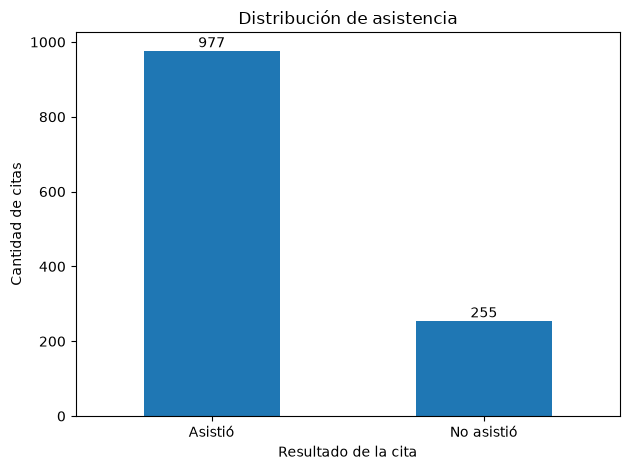

In [6]:
target_counts = (
    data["no_show"]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "Asistió",
            1: "No asistió",
        }
    )
)

target_percentages = (
    target_counts
    / target_counts.sum()
    * 100
).round(2)

target_summary = (
    pd.DataFrame(
        {
            "cantidad":
                target_counts,

            "porcentaje":
                target_percentages,
        }
    )
)

display(
    target_summary
)

axis = target_counts.plot(
    kind="bar",
    title=(
        "Distribución de asistencia"
    ),
    xlabel=(
        "Resultado de la cita"
    ),
    ylabel=(
        "Cantidad de citas"
    ),
    rot=0,
)

for container in axis.containers:
    axis.bar_label(
        container
    )

plt.tight_layout()
plt.show()


## 7. Estadísticas descriptivas


In [7]:
display(
    data[
        FEATURE_COLUMNS
    ]
    .describe()
    .transpose()
)


,count,mean,std,min,25%,50%,75%,max
day_of_week,1232.0,3.491071,1.703416,1.0,2.0,3.0000,5.0,7.0
appointment_hour,1232.0,12.330357,3.222653,1.0,10.0,12.0000,16.0,22.0
previous_completed,1232.0,2.760552,1.931054,0.0,1.0,3.0000,4.0,13.0
previous_no_show,1232.0,0.601461,0.854727,0.0,0.0,0.0000,1.0,3.0
previous_cancelled,1232.0,0.108766,0.311472,0.0,0.0,0.0000,0.0,1.0
previous_attendance_rate,1232.0,0.734975,0.333686,0.0,0.6,0.8333,1.0,1.0


## 8. División de entrenamiento y prueba

La separación se realiza por paciente utilizando
`GroupShuffleSplit`.

Esto evita que citas del mismo paciente aparezcan tanto
en entrenamiento como en prueba.


In [8]:
X = data[
    FEATURE_COLUMNS
].copy()

y = data[
    "no_show"
].copy()

groups = data[
    "patient_id"
].copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_index, test_index = next(
    splitter.split(
        X,
        y,
        groups=groups,
    )
)

X_train = (
    X.iloc[
        train_index
    ].copy()
)

X_test = (
    X.iloc[
        test_index
    ].copy()
)

y_train = (
    y.iloc[
        train_index
    ].copy()
)

y_test = (
    y.iloc[
        test_index
    ].copy()
)

train_patients = set(
    groups.iloc[
        train_index
    ].tolist()
)

test_patients = set(
    groups.iloc[
        test_index
    ].tolist()
)

repeated_patients = (
    train_patients
    .intersection(
        test_patients
    )
)

print(
    "Registros de entrenamiento:",
    len(X_train),
)

print(
    "Registros de prueba:",
    len(X_test),
)

print(
    "Pacientes de entrenamiento:",
    len(train_patients),
)

print(
    "Pacientes de prueba:",
    len(test_patients),
)

print(
    "Pacientes repetidos:",
    len(repeated_patients),
)


Registros de entrenamiento: 981
Registros de prueba: 251
Pacientes de entrenamiento: 131
Pacientes de prueba: 33
Pacientes repetidos: 0


## 9. Creación de los modelos


In [9]:
models: dict[str, Any] = {
    "Regresión logística":
        Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "classifier",
                    LogisticRegression(
                        max_iter=2000,
                        class_weight=(
                            "balanced"
                        ),
                        random_state=(
                            RANDOM_STATE
                        ),
                    ),
                ),
            ]
        ),

    "Bosque aleatorio":
        RandomForestClassifier(
            n_estimators=400,
            max_depth=10,
            min_samples_leaf=2,
            class_weight=(
                "balanced"
            ),
            random_state=(
                RANDOM_STATE
            ),
            n_jobs=-1,
        ),
}

print(
    "Modelos preparados:"
)

for model_name in models:
    print(
        f"- {model_name}"
    )


Modelos preparados:
- Regresión logística
- Bosque aleatorio


## 10. Entrenamiento y evaluación

La clase positiva es `no_show = 1`. Por lo tanto, la
precisión, el recall y el F1 se concentran en identificar
correctamente a los pacientes que no asistirán.


In [10]:
def evaluate_model(
    model_name: str,
    model: Any,
) -> dict[str, Any]:
    model.fit(
        X_train,
        y_train,
    )

    predictions = (
        model.predict(
            X_test
        )
    )

    probabilities = (
        model.predict_proba(
            X_test
        )[:, 1]
    )

    metrics = {
        "accuracy":
            accuracy_score(
                y_test,
                predictions,
            ),

        "precision_no_show":
            precision_score(
                y_test,
                predictions,
                pos_label=1,
                zero_division=0,
            ),

        "recall_no_show":
            recall_score(
                y_test,
                predictions,
                pos_label=1,
                zero_division=0,
            ),

        "f1_no_show":
            f1_score(
                y_test,
                predictions,
                pos_label=1,
                zero_division=0,
            ),

        "roc_auc":
            roc_auc_score(
                y_test,
                probabilities,
            ),
    }

    print(
        "=" * 65
    )

    print(
        model_name
    )

    print(
        "=" * 65
    )

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Asistió",
                "No asistió",
            ],
            zero_division=0,
        )
    )

    return {
        "name":
            model_name,

        "model":
            model,

        "metrics":
            metrics,

        "predictions":
            predictions,

        "probabilities":
            probabilities,
    }


evaluation_results = []

for model_name, model in models.items():
    result = evaluate_model(
        model_name,
        model,
    )

    evaluation_results.append(
        result
    )


Regresión logística
              precision    recall  f1-score   support

     Asistió       0.97      0.50      0.66       185
  No asistió       0.41      0.95      0.57        66

    accuracy                           0.62       251
   macro avg       0.69      0.73      0.62       251
weighted avg       0.82      0.62      0.64       251

Bosque aleatorio
              precision    recall  f1-score   support

     Asistió       0.92      0.79      0.85       185
  No asistió       0.58      0.82      0.68        66

    accuracy                           0.80       251
   macro avg       0.75      0.80      0.77       251
weighted avg       0.83      0.80      0.81       251



## 11. Comparación de resultados


In [11]:
comparison_rows = []

for result in evaluation_results:
    comparison_rows.append(
        {
            "modelo":
                result["name"],

            **result["metrics"],
        }
    )

comparison = (
    pd.DataFrame(
        comparison_rows
    )
    .sort_values(
        by=[
            "f1_no_show",
            "roc_auc",
        ],
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    comparison.style.format(
        {
            "accuracy":
                "{:.4f}",

            "precision_no_show":
                "{:.4f}",

            "recall_no_show":
                "{:.4f}",

            "f1_no_show":
                "{:.4f}",

            "roc_auc":
                "{:.4f}",
        }
    )
)


,modelo,accuracy,precision_no_show,recall_no_show,f1_no_show,roc_auc
0,Bosque aleatorio,0.7968,0.5806,0.8182,0.6792,0.9064
1,Regresión logística,0.6215,0.4065,0.9545,0.5701,0.6819


## 12. Selección del mejor modelo

El mejor modelo se selecciona principalmente por el
valor F1 de la clase de inasistencia.


In [12]:
best_result = max(
    evaluation_results,
    key=lambda result: (
        result["metrics"][
            "f1_no_show"
        ],
        result["metrics"][
            "roc_auc"
        ],
    ),
)

best_model_name = (
    best_result["name"]
)

best_model = (
    best_result["model"]
)

best_metrics = (
    best_result["metrics"]
)

best_predictions = (
    best_result["predictions"]
)

best_probabilities = (
    best_result["probabilities"]
)

print(
    "Mejor modelo:",
    best_model_name,
)

for (
    metric_name,
    metric_value,
) in best_metrics.items():
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )


Mejor modelo: Bosque aleatorio
accuracy: 0.7968
precision_no_show: 0.5806
recall_no_show: 0.8182
f1_no_show: 0.6792
roc_auc: 0.9064


## 13. Matriz de confusión


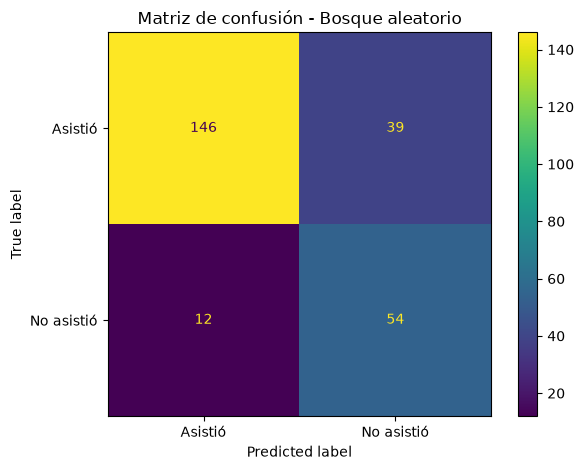

Matriz guardada en: C:\Users\rmera\OneDrive\Desktop\proyecto final rubi ramos\RubiRamos\ML\matriz_confusion.png


In [13]:
matrix = confusion_matrix(
    y_test,
    best_predictions,
)

matrix_display = (
    ConfusionMatrixDisplay(
        confusion_matrix=(
            matrix
        ),
        display_labels=[
            "Asistió",
            "No asistió",
        ],
    )
)

matrix_display.plot(
    values_format="d"
)

plt.title(
    "Matriz de confusión - "
    + best_model_name
)

plt.tight_layout()

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Matriz guardada en:",
    CONFUSION_MATRIX_PATH,
)


## 14. Importancia de las variables


,variable,importancia
0,previous_completed,0.347043
1,previous_attendance_rate,0.298902
2,appointment_hour,0.115028
3,previous_no_show,0.099806
4,previous_cancelled,0.075466
5,day_of_week,0.063755


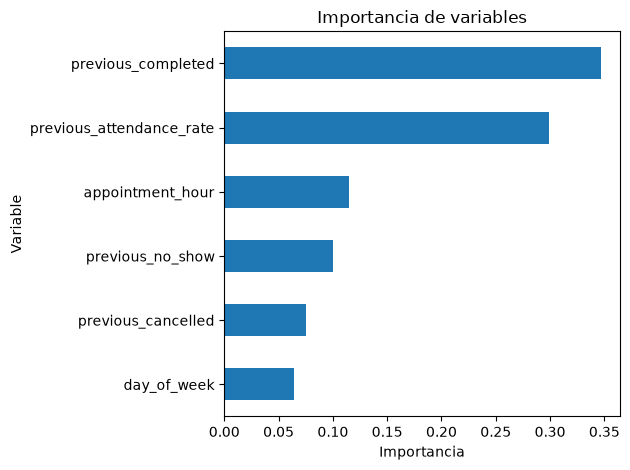

In [14]:
def get_feature_importance(
    model_name: str,
    model: Any,
) -> pd.DataFrame:
    if (
        model_name
        == "Bosque aleatorio"
    ):
        importance_values = (
            model.feature_importances_
        )

    elif (
        model_name
        == "Regresión logística"
    ):
        classifier = (
            model.named_steps[
                "classifier"
            ]
        )

        importance_values = abs(
            classifier.coef_[0]
        )

    else:
        raise ValueError(
            "Modelo no reconocido."
        )

    result = pd.DataFrame(
        {
            "variable":
                FEATURE_COLUMNS,

            "importancia":
                importance_values,
        }
    )

    return (
        result
        .sort_values(
            by="importancia",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


feature_importance = (
    get_feature_importance(
        best_model_name,
        best_model,
    )
)

display(
    feature_importance
)

(
    feature_importance
    .sort_values(
        by="importancia",
        ascending=True,
    )
    .plot(
        kind="barh",
        x="variable",
        y="importancia",
        legend=False,
        title=(
            "Importancia de variables"
        ),
        xlabel="Importancia",
        ylabel="Variable",
    )
)

plt.tight_layout()
plt.show()


## 15. Exportación del modelo y resultados

El modelo se guarda en el archivo
`modelo_inasistencia.joblib`.


In [15]:
model_package = {
    "model":
        best_model,

    "feature_columns":
        FEATURE_COLUMNS,

    "model_name":
        best_model_name,

    "target_column":
        "no_show",

    "positive_class":
        1,

    "metrics":
        best_metrics,

    "random_state":
        RANDOM_STATE,

    "trained_at_utc":
        pd.Timestamp.now(
            tz="UTC"
        ).isoformat(),
}

joblib.dump(
    model_package,
    MODEL_PATH,
)

serializable_metrics = {
    "best_model":
        best_model_name,

    **{
        metric_name:
            float(metric_value)

        for (
            metric_name,
            metric_value,
        ) in best_metrics.items()
    },
}

with METRICS_PATH.open(
    "w",
    encoding="utf-8",
) as metrics_file:
    json.dump(
        serializable_metrics,
        metrics_file,
        indent=4,
        ensure_ascii=False,
    )

feature_importance.to_csv(
    IMPORTANCE_PATH,
    index=False,
)

test_results = (
    data.iloc[
        test_index
    ].copy()
)

test_results[
    "actual_no_show"
] = y_test.to_numpy()

test_results[
    "predicted_no_show"
] = best_predictions

test_results[
    "predicted_no_show_probability"
] = best_probabilities

test_results.to_csv(
    PREDICTIONS_PATH,
    index=False,
)

print(
    "Archivos generados:"
)

print(
    "- Modelo:",
    MODEL_PATH,
)

print(
    "- Métricas:",
    METRICS_PATH,
)

print(
    "- Importancias:",
    IMPORTANCE_PATH,
)

print(
    "- Predicciones:",
    PREDICTIONS_PATH,
)

print(
    "- Matriz:",
    CONFUSION_MATRIX_PATH,
)


Archivos generados:
- Modelo: C:\Users\rmera\OneDrive\Desktop\proyecto final rubi ramos\RubiRamos\ML\modelo_inasistencia.joblib
- Métricas: C:\Users\rmera\OneDrive\Desktop\proyecto final rubi ramos\RubiRamos\ML\metricas_modelo.json
- Importancias: C:\Users\rmera\OneDrive\Desktop\proyecto final rubi ramos\RubiRamos\ML\importancia_variables.csv
- Predicciones: C:\Users\rmera\OneDrive\Desktop\proyecto final rubi ramos\RubiRamos\ML\predicciones_prueba.csv
- Matriz: C:\Users\rmera\OneDrive\Desktop\proyecto final rubi ramos\RubiRamos\ML\matriz_confusion.png


## 16. Prueba del modelo guardado


In [16]:
loaded_package = joblib.load(
    MODEL_PATH
)

loaded_model = (
    loaded_package["model"]
)

loaded_features = (
    loaded_package[
        "feature_columns"
    ]
)

sample = (
    X_test.iloc[
        [0]
    ][loaded_features]
)

sample_probability = float(
    loaded_model.predict_proba(
        sample
    )[0][1]
)

sample_prediction = int(
    loaded_model.predict(
        sample
    )[0]
)

print(
    "Probabilidad de inasistencia:",
    round(
        sample_probability * 100,
        2,
    ),
    "%",
)

print(
    "Resultado:",
    (
        "No asistirá"
        if sample_prediction == 1
        else "Sí asistirá"
    ),
)


Probabilidad de inasistencia: 0.0 %
Resultado: Sí asistirá


## 17. Función para probar una cita nueva


In [17]:
def predict_new_appointment(
    *,
    age: int,
    gender_female: int,
    day_of_week: int,
    appointment_hour: int,
    is_saturday: int,
    previous_completed: int,
    previous_no_show: int,
    previous_cancelled: int,
) -> dict[str, Any]:
    previous_appointments = (
        previous_completed
        + previous_no_show
        + previous_cancelled
    )

    attendance_total = (
        previous_completed
        + previous_no_show
    )

    attendance_rate = (
        previous_completed
        / attendance_total
        if attendance_total > 0
        else 0.0
    )

    values = {
        "age":
            age,

        "gender_female":
            gender_female,

        "day_of_week":
            day_of_week,

        "appointment_hour":
            appointment_hour,

        "is_saturday":
            is_saturday,

        "previous_completed":
            previous_completed,

        "previous_no_show":
            previous_no_show,

        "previous_cancelled":
            previous_cancelled,

        "previous_appointments":
            previous_appointments,

        "previous_attendance_rate":
            attendance_rate,
    }

    input_data = pd.DataFrame(
        [values],
        columns=loaded_features,
    )

    model_probability = float(
        loaded_model.predict_proba(
            input_data
        )[0][1]
    )

    historical_probability = (
        previous_no_show
        / attendance_total
        if attendance_total >= 3
        else 0.0
    )

    final_probability = max(
        model_probability,
        historical_probability,
    )

    final_probability = min(
        max(
            final_probability,
            0.0,
        ),
        1.0,
    )

    attendance_probability = (
        1.0
        - final_probability
    )

    if final_probability >= 0.50:
        risk_level = "Alto"

        recommendation = (
            "Solicitar anticipo obligatorio "
            "y enviar recordatorios "
            "adicionales."
        )

    elif final_probability >= 0.25:
        risk_level = "Medio"

        recommendation = (
            "Enviar un recordatorio "
            "adicional antes de la cita."
        )

    else:
        risk_level = "Bajo"

        recommendation = (
            "Mantener el proceso normal "
            "de confirmación."
        )

    return {
        "model_no_show_percentage":
            round(
                model_probability
                * 100,
                2,
            ),

        "historical_no_show_percentage":
            round(
                historical_probability
                * 100,
                2,
            ),

        "final_no_show_percentage":
            round(
                final_probability
                * 100,
                2,
            ),

        "attendance_percentage":
            round(
                attendance_probability
                * 100,
                2,
            ),

        "risk_level":
            risk_level,

        "prediction":
            (
                "No asistirá"
                if final_probability
                >= 0.50
                else "Sí asistirá"
            ),

        "recommendation":
            recommendation,
    }


In [18]:
example_prediction = (
    predict_new_appointment(
        age=52,
        gender_female=1,
        day_of_week=7,
        appointment_hour=10,
        is_saturday=0,
        previous_completed=5,
        previous_no_show=3,
        previous_cancelled=0,
    )
)

example_prediction


{'model_no_show_percentage': 16.4,
 'historical_no_show_percentage': 37.5,
 'final_no_show_percentage': 37.5,
 'attendance_percentage': 62.5,
 'risk_level': 'Medio',
 'prediction': 'Sí asistirá',
 'recommendation': 'Enviar un recordatorio adicional antes de la cita.'}

## 18. Conclusiones

Se compararon dos algoritmos de clasificación y se
seleccionó el que obtuvo el mejor F1 para identificar
inasistencias.

La separación se realizó por paciente para evitar fuga
de información.

El anticipo no se utilizó como entrada del modelo, ya
que la predicción será utilizada para recomendar cuándo
solicitarlo.

El archivo `modelo_inasistencia.joblib` puede ser
utilizado por FastAPI para ofrecer predicciones a la
aplicación Next.js.

Los resultados actuales dependen principalmente de
datos sintéticos. Para una implementación real, el
modelo deberá reentrenarse con información real y
actualizarse periódicamente.
